# WOD-E2E Val Set — Data Audit
Checks: (1) file inventory, (2) npz contents, (3) label coverage, (4) sample visualization

In [6]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

DATA_DIR = Path('../data/processed/waymo_e2e/val')
LABEL_JSON = Path('../data/val_sequence_name_to_scenario_cluster.json')

print(f'Data dir exists: {DATA_DIR.exists()}')
print(f'Label JSON exists: {LABEL_JSON.exists()}')

Data dir exists: True
Label JSON exists: True


## 1. File Inventory

Total .npz files: 106,360
Total size: 13.05 GB
Suspiciously small files (<1KB): 0

File size stats (KB):
  min:    66.2
  median: 123.1
  max:    161.2


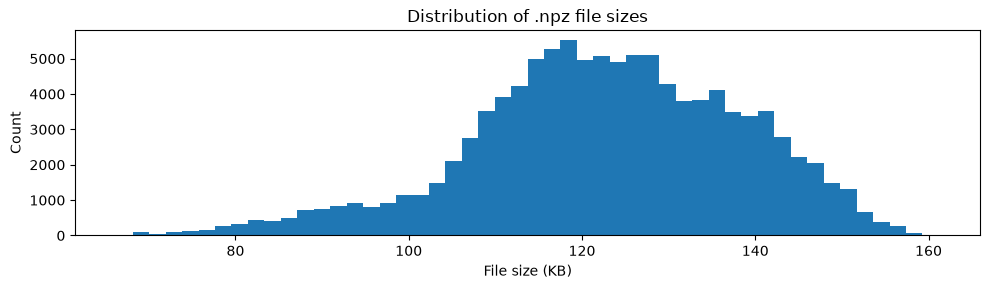

In [7]:
npz_files = sorted(DATA_DIR.glob('**/*.npz'))
total_bytes = sum(f.stat().st_size for f in npz_files)
total_gb = total_bytes / 1e9

print(f'Total .npz files: {len(npz_files):,}')
print(f'Total size: {total_gb:.2f} GB')

# Check for zero-byte / suspiciously small files
small_files = [f for f in npz_files if f.stat().st_size < 1000]
print(f'Suspiciously small files (<1KB): {len(small_files)}')
if small_files:
    for f in small_files[:10]:
        print(f'  {f.name} — {f.stat().st_size} bytes')

# File size distribution
sizes_kb = [f.stat().st_size / 1e3 for f in npz_files]
print(f'\nFile size stats (KB):')
print(f'  min:    {min(sizes_kb):.1f}')
print(f'  median: {np.median(sizes_kb):.1f}')
print(f'  max:    {max(sizes_kb):.1f}')

plt.figure(figsize=(10, 3))
plt.hist(sizes_kb, bins=50)
plt.xlabel('File size (KB)')
plt.ylabel('Count')
plt.title('Distribution of .npz file sizes')
plt.tight_layout()
plt.show()

In [8]:
# Parse sequence IDs from filenames
# StandardE2E names files as <sequence_id>_<frame_idx>.npz or similar — inspect actual pattern
print('Sample filenames (first 10):')
for f in npz_files[:10]:
    print(f'  {f.name}')

print('\nSample filenames (last 10):')
for f in npz_files[-10:]:
    print(f'  {f.name}')

Sample filenames (first 10):
  0075c28f1f1a68c4c1c8dcf37958046b_100.npz
  0075c28f1f1a68c4c1c8dcf37958046b_101.npz
  0075c28f1f1a68c4c1c8dcf37958046b_102.npz
  0075c28f1f1a68c4c1c8dcf37958046b_103.npz
  0075c28f1f1a68c4c1c8dcf37958046b_104.npz
  0075c28f1f1a68c4c1c8dcf37958046b_105.npz
  0075c28f1f1a68c4c1c8dcf37958046b_106.npz
  0075c28f1f1a68c4c1c8dcf37958046b_107.npz
  0075c28f1f1a68c4c1c8dcf37958046b_108.npz
  0075c28f1f1a68c4c1c8dcf37958046b_109.npz

Sample filenames (last 10):
  fe64be81fe42f8a9a901da26ba0179c1_90.npz
  fe64be81fe42f8a9a901da26ba0179c1_91.npz
  fe64be81fe42f8a9a901da26ba0179c1_92.npz
  fe64be81fe42f8a9a901da26ba0179c1_93.npz
  fe64be81fe42f8a9a901da26ba0179c1_94.npz
  fe64be81fe42f8a9a901da26ba0179c1_95.npz
  fe64be81fe42f8a9a901da26ba0179c1_96.npz
  fe64be81fe42f8a9a901da26ba0179c1_97.npz
  fe64be81fe42f8a9a901da26ba0179c1_98.npz
  fe64be81fe42f8a9a901da26ba0179c1_99.npz


## 2. NPZ Contents

In [9]:
# Inspect a sample of npz files
SAMPLE_N = 5
sample_files = npz_files[::max(1, len(npz_files) // SAMPLE_N)][:SAMPLE_N]

for fpath in sample_files:
    print(f'\n--- {fpath.name} ---')
    try:
        data = np.load(fpath, allow_pickle=True)
        for key in data.files:
            val = data[key]
            if hasattr(val, 'shape'):
                print(f'  {key}: shape={val.shape}, dtype={val.dtype}')
            else:
                print(f'  {key}: {type(val)} = {val}')
    except Exception as e:
        print(f'  ERROR loading: {e}')


--- 0075c28f1f1a68c4c1c8dcf37958046b_100.npz ---
  dataset_name: shape=(), dtype=<U9
  segment_id: shape=(), dtype=<U32
  frame_id: shape=(), dtype=int64
  timestamp: shape=(), dtype=float64
  split: shape=(), dtype=<U3
  global_position: shape=(), dtype=object
  filename: shape=(), dtype=<U54
  aux_data: shape=(), dtype=object
  timestamp_diff: shape=(), dtype=object
  _modality_data: shape=(), dtype=object

--- 2debdc4fc91a505493ab4b647080e720_101.npz ---
  dataset_name: shape=(), dtype=<U9
  segment_id: shape=(), dtype=<U32
  frame_id: shape=(), dtype=int64
  timestamp: shape=(), dtype=float64
  split: shape=(), dtype=<U3
  global_position: shape=(), dtype=object
  filename: shape=(), dtype=<U54
  aux_data: shape=(), dtype=object
  timestamp_diff: shape=(), dtype=object
  _modality_data: shape=(), dtype=object

--- 6490e84a1296de6e49aa008023e40ebb_68.npz ---
  dataset_name: shape=(), dtype=<U9
  segment_id: shape=(), dtype=<U32
  frame_id: shape=(), dtype=int64
  timestamp: shape=(

In [11]:
data = np.load(npz_files[0], allow_pickle=True)
modality = data['_modality_data'].item()
print(type(modality))
print(modality.keys() if hasattr(modality, 'keys') else modality)

aux = data['aux_data'].item()
print(type(aux))
print(aux.keys() if hasattr(aux, 'keys') else aux)

<class 'dict'>
dict_keys([<Modality.CAMERAS: 'cameras'>, <Modality.INTENT: 'intent'>, <Modality.FUTURE_STATES: 'future_states'>, <Modality.PAST_STATES: 'past_states'>])
<class 'dict'>
dict_keys(['preference_trajectories'])


In [12]:
data = np.load(npz_files[0], allow_pickle=True)
modality = data['_modality_data'].item()

from enum import Enum

# Inspect cameras
cameras = modality[list(modality.keys())[0]]  # CAMERAS
print(type(cameras))
print(cameras.keys() if hasattr(cameras, 'keys') else cameras)

<class 'numpy.ndarray'>
[[[36 23 15]
  [39 27 20]
  [32 14 14]
  ...
  [26 21 17]
  [25 21 15]
  [26 11  8]]

 [[32 27 18]
  [31 20 17]
  [27 17 15]
  ...
  [25 15  9]
  [20 11 12]
  [22 17 15]]

 [[31 22 21]
  [39 19 21]
  [30 20  8]
  ...
  [34 21 20]
  [22 23 17]
  [28 12 14]]

 ...

 [[19 14 12]
  [28 26 14]
  [38 24 23]
  ...
  [10  9 11]
  [21 11  7]
  [17 10  3]]

 [[25 24 19]
  [31 21 12]
  [35 23 15]
  ...
  [16  9 16]
  [21 13 16]
  [13 11  9]]

 [[32 19 12]
  [32 21 17]
  [20 28 17]
  ...
  [21 12  9]
  [13  9 10]
  [21 13 12]]]


In [13]:
# Inspect past/future states
past = modality[list(modality.keys())[3]]   # PAST_STATES
future = modality[list(modality.keys())[2]] # FUTURE_STATES

print('PAST_STATES:')
print(type(past))
print(past.keys() if hasattr(past, 'keys') else past)

print('\nFUTURE_STATES:')
print(type(future))
print(future.keys() if hasattr(future, 'keys') else future)

PAST_STATES:
<class 'standard_e2e.data_structures.trajectory_data.Trajectory'>
Trajectory(N=16, isEmpty=False,             score=None, comps=[X:(16,), IS_VALID:(16,), Y:(16,), VELOCITY_X:(16,), VELOCITY_Y:(16,), ACCELERATION_X:(16,), ACCELERATION_Y:(16,), TIMESTAMP:(16,)])

FUTURE_STATES:
<class 'standard_e2e.data_structures.trajectory_data.Trajectory'>
Trajectory(N=20, isEmpty=False,             score=None, comps=[X:(20,), IS_VALID:(20,), Y:(20,), Z:(20,), TIMESTAMP:(20,)])


In [19]:
from standard_e2e.data_structures.trajectory_data import TrajectoryComponent as TC

print('X:  ', past.get(TC.X))
print('Y:  ', past.get(TC.Y))
print('VX: ', past.get(TC.VELOCITY_X))
print('VY: ', past.get(TC.VELOCITY_Y))

print('\nFUTURE:')
future = modality[keys[2]]
print('X:  ', future.get(TC.X))
print('Y:  ', future.get(TC.Y))

X:   [[-41.898438 ]
 [-39.078125 ]
 [-36.256836 ]
 [-33.439453 ]
 [-30.623047 ]
 [-27.8125   ]
 [-25.00879  ]
 [-22.20996  ]
 [-19.416504 ]
 [-16.625    ]
 [-13.8359375]
 [-11.054199 ]
 [ -8.277832 ]
 [ -5.510254 ]
 [ -2.7519531]
 [  0.       ]]
Y:   [[-0.02246094]
 [-0.0234375 ]
 [-0.02539062]
 [-0.03417969]
 [-0.04199219]
 [-0.05078125]
 [-0.05957031]
 [-0.06054688]
 [-0.05566406]
 [-0.04589844]
 [-0.03027344]
 [-0.01660156]
 [-0.00683594]
 [-0.00097656]
 [ 0.00195312]
 [ 0.        ]]
VX:  [[11.276426 ]
 [11.289157 ]
 [11.252729 ]
 [11.2661915]
 [11.223881 ]
 [11.208728 ]
 [11.179485 ]
 [11.175459 ]
 [11.157807 ]
 [11.143965 ]
 [11.117719 ]
 [11.08975  ]
 [11.049738 ]
 [11.026296 ]
 [10.977868 ]
 [10.977868 ]]
VY:  [[ 0.00250626]
 [-0.00393187]
 [-0.02715017]
 [-0.03033175]
 [-0.03704184]
 [-0.0325895 ]
 [-0.01815033]
 [ 0.01635925]
 [ 0.04943798]
 [ 0.06534276]
 [ 0.04491539]
 [ 0.04121938]
 [ 0.03083147]
 [ 0.02386683]
 [-0.00628908]
 [-0.00628908]]

FUTURE:
X:   [[ 2.739746]
 [ 5.

In [20]:
print(f'Image shape: {cameras.shape}')
print(f'past.components: {past.components}')
print(f'timestamp_diff: {data["timestamp_diff"].item()}')

Image shape: (142, 384, 3)
past.components: <bound method Trajectory.components of Trajectory(N=16, isEmpty=False,             score=None, comps=[X:(16,), IS_VALID:(16,), Y:(16,), VELOCITY_X:(16,), VELOCITY_Y:(16,), ACCELERATION_X:(16,), ACCELERATION_Y:(16,), TIMESTAMP:(16,)])>
timestamp_diff: None


In [21]:
print(f'timestamps: {past.get(TC.TIMESTAMP).flatten()}')
print(f'frame_id:   {data["timestamp"].item()}')

# How many unique timestamps = frame rate estimate
ts = past.get(TC.TIMESTAMP).flatten()
diffs = np.diff(ts)
print(f'mean frame interval: {diffs.mean():.4f}s  (~{1/diffs.mean():.1f} fps)')

timestamps: [-3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25 -2.   -1.75 -1.5  -1.25 -1.
 -0.75 -0.5  -0.25  0.  ]
frame_id:   10.0
mean frame interval: 0.2500s  (~4.0 fps)


In [22]:
# Check for temporal/frame metadata keys across a larger sample
AUDIT_N = 200
audit_files = npz_files[::max(1, len(npz_files) // AUDIT_N)][:AUDIT_N]

key_counter = Counter()
errors = []

for fpath in audit_files:
    try:
        data = np.load(fpath, allow_pickle=True)
        for key in data.files:
            key_counter[key] += 1
    except Exception as e:
        errors.append((fpath.name, str(e)))

print(f'Keys found across {AUDIT_N} sampled files:')
for key, count in key_counter.most_common():
    print(f'  {key}: present in {count}/{AUDIT_N} files')

if errors:
    print(f'\nErrors ({len(errors)}):')
    for name, err in errors[:10]:
        print(f'  {name}: {err}')

Keys found across 200 sampled files:
  dataset_name: present in 200/200 files
  segment_id: present in 200/200 files
  frame_id: present in 200/200 files
  timestamp: present in 200/200 files
  split: present in 200/200 files
  global_position: present in 200/200 files
  filename: present in 200/200 files
  aux_data: present in 200/200 files
  timestamp_diff: present in 200/200 files
  _modality_data: present in 200/200 files


## 3. Label Coverage

In [24]:
# Peek at the JSON structure
first_key = list(labels.keys())[0]
print(f'Key: {first_key}')
print(f'Value: {labels[first_key]}')

Key: ea9000098840a70220698bd12b167f97
Value: {'scenario_cluster': 'Pedestrian'}


In [25]:
labeled_sequences = set(labels.keys())
print(f'Labeled sequences in JSON: {len(labeled_sequences)}')

class_counts = Counter(v['scenario_cluster'] for v in labels.values())
print('\nClass distribution:')
for cls, count in sorted(class_counts.items()):
    print(f'  {cls}: {count}')

Labeled sequences in JSON: 479

Class distribution:
  Construction: 15
  Cut_ins: 20
  Cyclist: 71
  Foreign Object Debris: 78
  Interections: 116
  Multi-Lane Maneuvers: 42
  Others: 22
  Pedestrian: 52
  Single-Lane Maneuvers: 38
  Special Vehicles: 25


In [26]:
# Infer sequence IDs from filenames
# Adjust this parsing logic based on actual filename pattern observed above
# Common StandardE2E pattern: <sequence_name>_<frame_idx>.npz

def parse_sequence_id(fname):
    """Extract sequence ID from npz filename. Adjust if pattern differs."""
    stem = Path(fname).stem
    # Try splitting on last underscore to remove frame index
    parts = stem.rsplit('_', 1)
    if len(parts) == 2 and parts[1].isdigit():
        return parts[0]
    return stem  # fallback: whole stem is the sequence id

# Build sequence -> file list mapping
seq_to_files = defaultdict(list)
for f in npz_files:
    seq_id = parse_sequence_id(f.name)
    seq_to_files[seq_id].append(f)

downloaded_sequences = set(seq_to_files.keys())
print(f'Sequences found in downloaded data: {len(downloaded_sequences)}')

# Coverage check
missing = labeled_sequences - downloaded_sequences
extra = downloaded_sequences - labeled_sequences

print(f'\nLabeled sequences missing from download: {len(missing)}')
if missing:
    for s in sorted(missing)[:20]:
        print(f'  {s}')

print(f'\nDownloaded sequences not in label JSON: {len(extra)}')
if extra:
    for s in sorted(extra)[:20]:
        print(f'  {s}')

Sequences found in downloaded data: 479

Labeled sequences missing from download: 0

Downloaded sequences not in label JSON: 0


Frames per sequence:
  min:    99
  median: 229
  max:    230


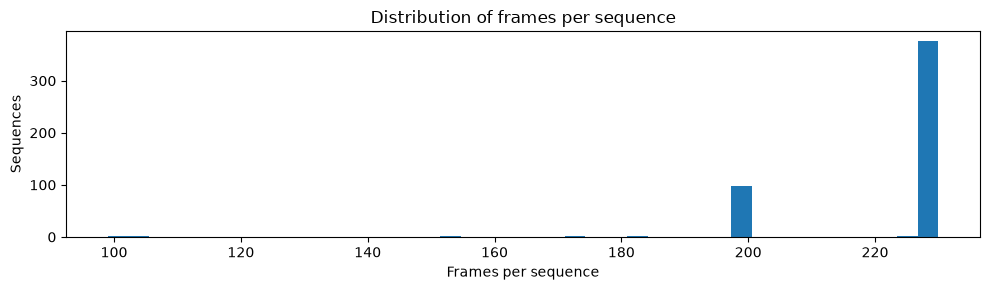


Frames per sequence by class (median):


In [27]:
# Frames per sequence distribution
frames_per_seq = {seq: len(files) for seq, files in seq_to_files.items()}
counts = list(frames_per_seq.values())

print(f'Frames per sequence:')
print(f'  min:    {min(counts)}')
print(f'  median: {int(np.median(counts))}')
print(f'  max:    {max(counts)}')

plt.figure(figsize=(10, 3))
plt.hist(counts, bins=40)
plt.xlabel('Frames per sequence')
plt.ylabel('Sequences')
plt.title('Distribution of frames per sequence')
plt.tight_layout()
plt.show()

# Break down by class
print('\nFrames per sequence by class (median):')
for cls in sorted(class_counts.keys()):
    cls_seqs = [seq for seq in seq_to_files if labels.get(seq) == cls]
    cls_counts = [len(seq_to_files[s]) for s in cls_seqs]
    if cls_counts:
        print(f'  {cls}: {len(cls_seqs)} seqs, median {int(np.median(cls_counts))} frames')

In [28]:
print('Frames per sequence by class:')
for cls in sorted(class_counts.keys()):
    cls_seqs = [seq for seq in seq_to_files if labels.get(seq, {}).get('scenario_cluster') == cls]
    cls_frame_counts = [len(seq_to_files[s]) for s in cls_seqs]
    if cls_frame_counts:
        print(f'  {cls:30s}: {len(cls_seqs):3d} seqs | min={min(cls_frame_counts):3d} median={int(np.median(cls_frame_counts)):3d} max={max(cls_frame_counts):3d}')

Frames per sequence by class:
  Construction                  :  15 seqs | min=199 median=225 max=229
  Cut_ins                       :  20 seqs | min=199 median=229 max=229
  Cyclist                       :  71 seqs | min=152 median=229 max=230
  Foreign Object Debris         :  78 seqs | min=182 median=229 max=230
  Interections                  : 116 seqs | min=199 median=229 max=230
  Multi-Lane Maneuvers          :  42 seqs | min=198 median=229 max=230
  Others                        :  22 seqs | min=105 median=229 max=230
  Pedestrian                    :  52 seqs | min= 99 median=229 max=229
  Single-Lane Maneuvers         :  38 seqs | min=174 median=229 max=230
  Special Vehicles              :  25 seqs | min=200 median=229 max=230


## 4. Sample Visualization

Image shape: (142, 384, 3), dtype: uint8


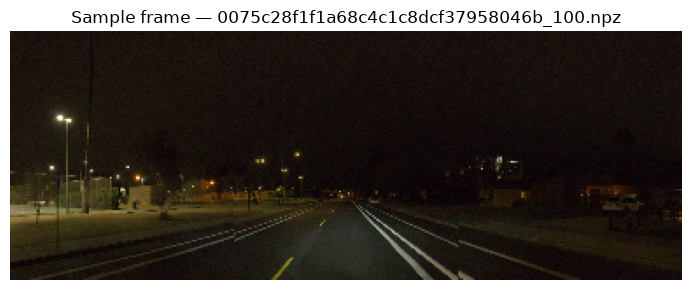

In [31]:
from standard_e2e.data_structures.trajectory_data import TrajectoryComponent as TC

def load_image(fpath):
    data = np.load(fpath, allow_pickle=True)
    modality = data['_modality_data'].item()
    keys = list(modality.keys())
    img = modality[keys[0]]  # CAMERAS is always first key
    if img.dtype in [np.float32, np.float64]:
        img = np.clip(img, 0, 1)
    else:
        img = img.astype(np.uint8)
    return img

# Test it
img = load_image(npz_files[0])
print(f'Image shape: {img.shape}, dtype: {img.dtype}')
plt.figure(figsize=(14, 3))
plt.imshow(img)
plt.axis('off')
plt.title(f'Sample frame — {npz_files[0].name}')
plt.tight_layout()
plt.show()

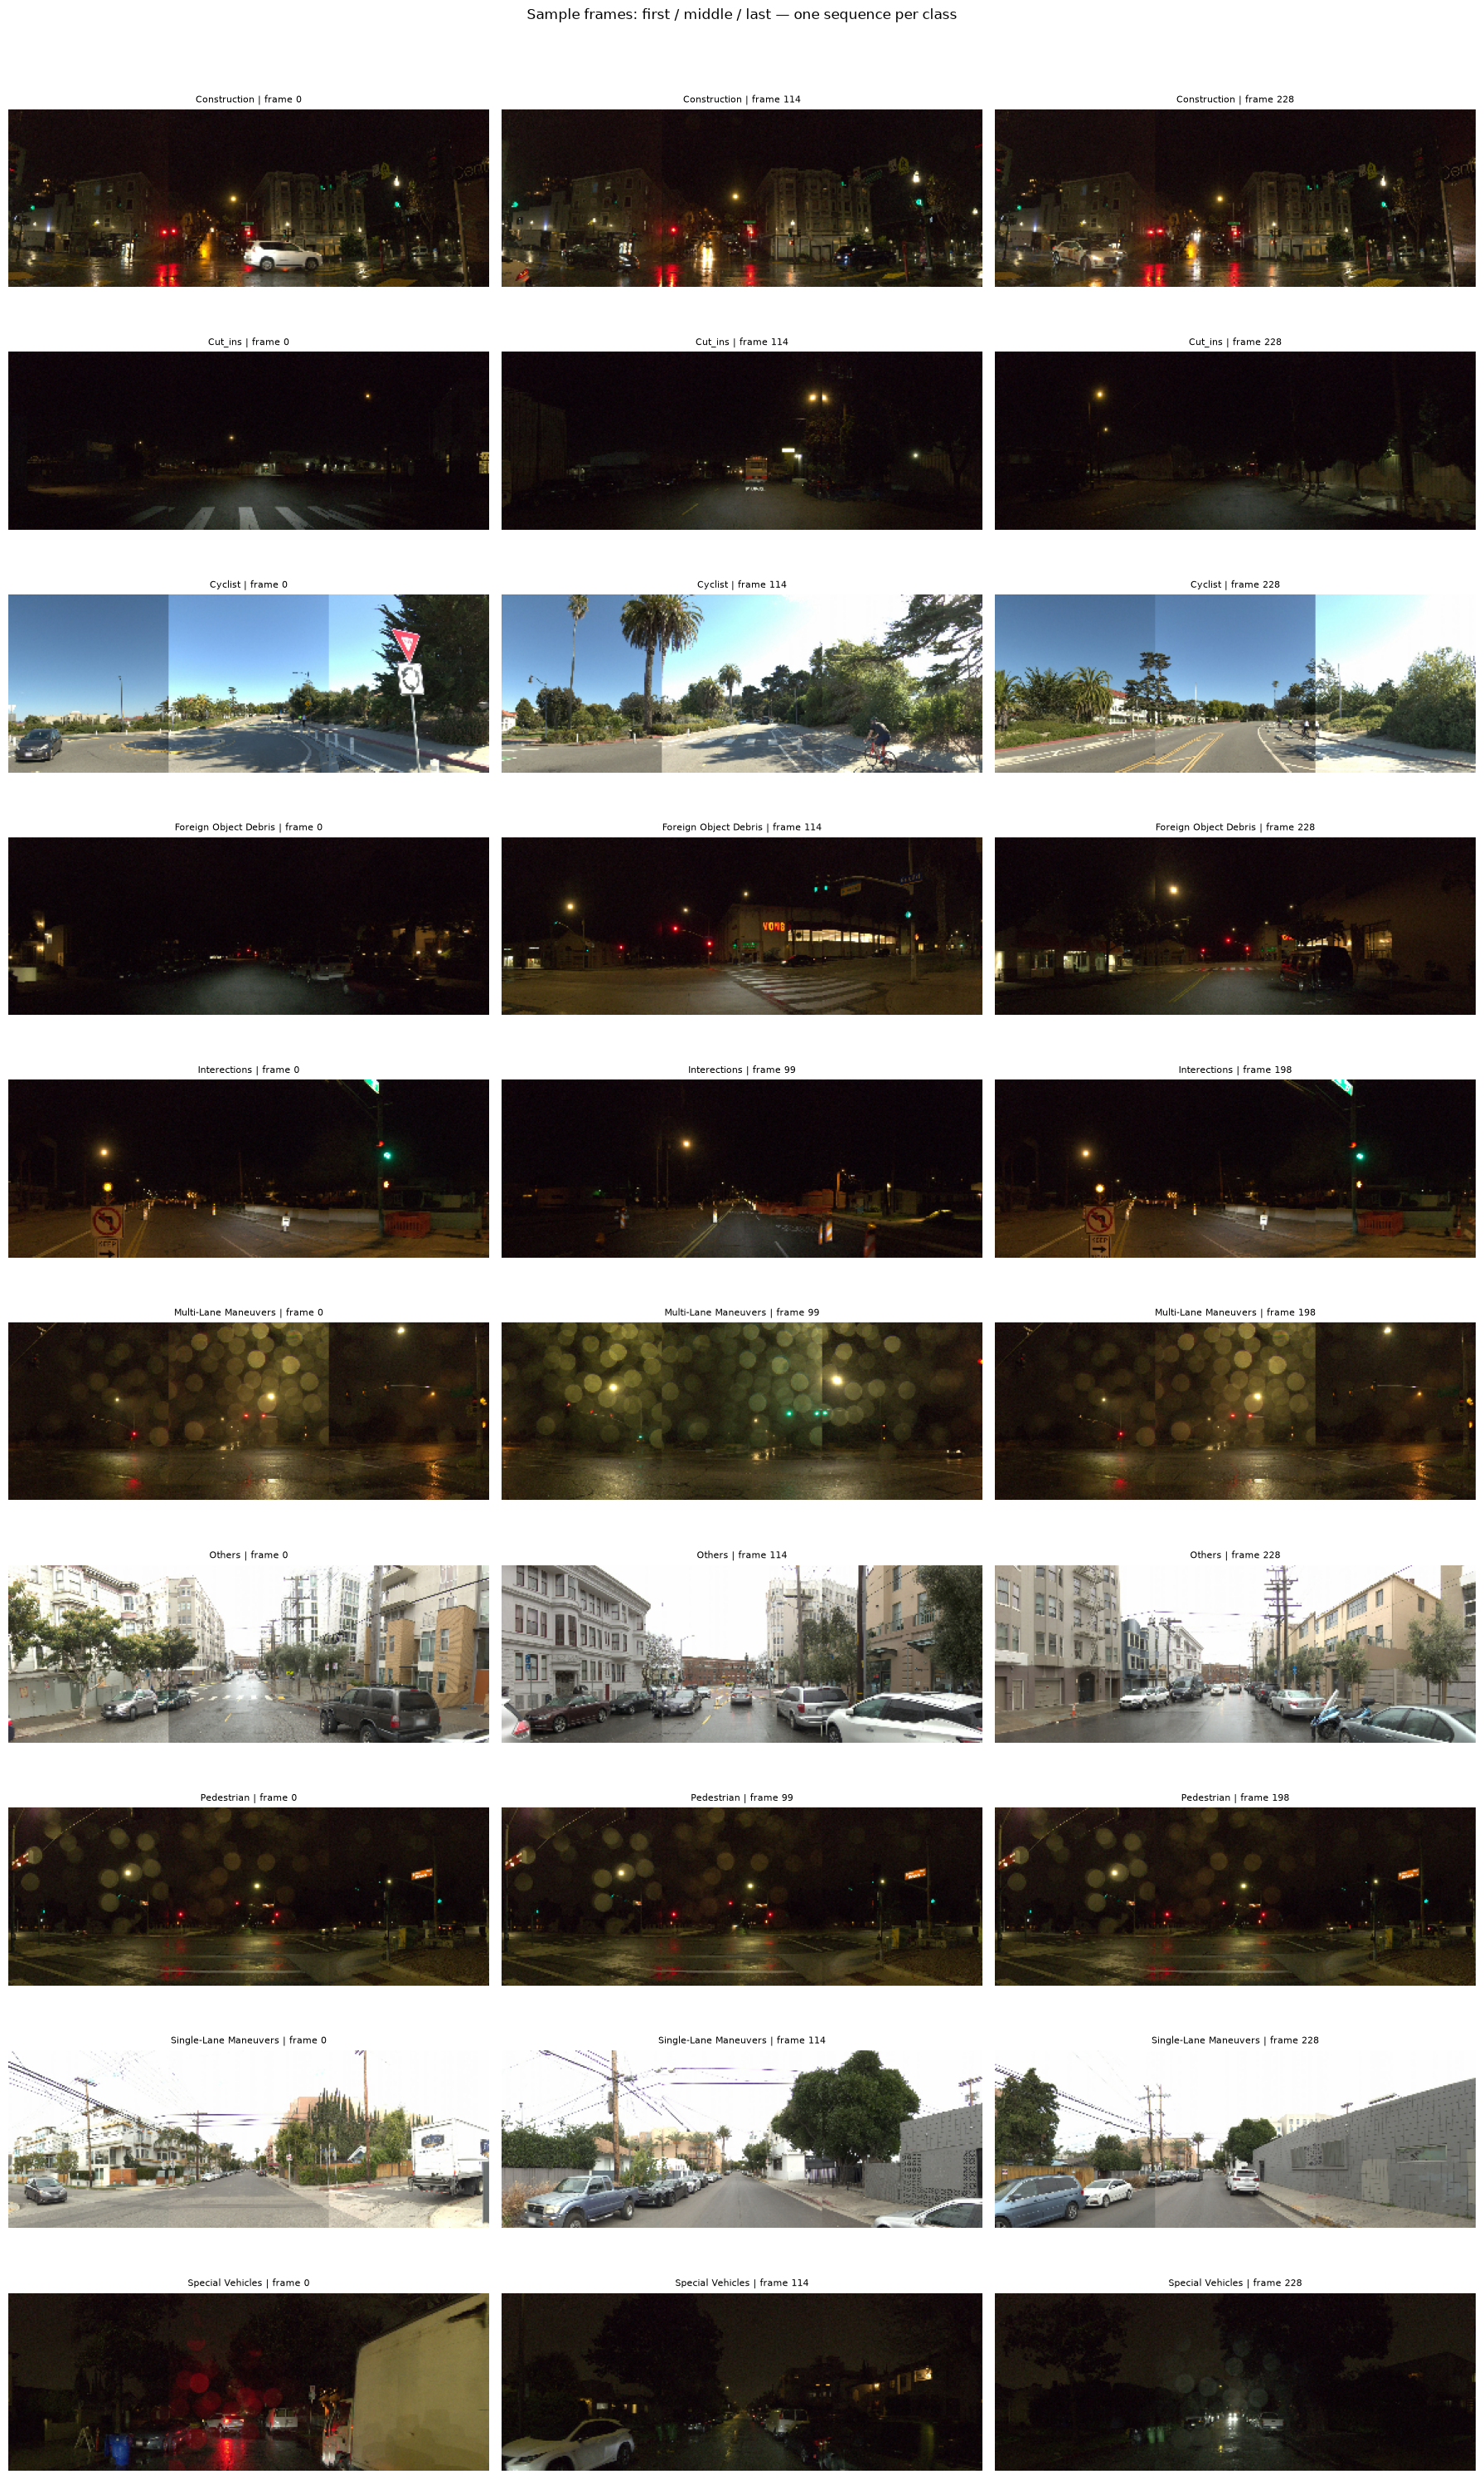

In [32]:
classes = sorted(class_counts.keys())
fig, axes = plt.subplots(len(classes), 3, figsize=(18, 3 * len(classes)))

rng = np.random.default_rng(42)

for row_idx, cls in enumerate(classes):
    cls_seqs = [seq for seq in seq_to_files if labels.get(seq, {}).get('scenario_cluster') == cls]
    seq = cls_seqs[rng.integers(len(cls_seqs))]
    files = sorted(seq_to_files[seq])
    n = len(files)
    sample_idxs = [0, n // 2, n - 1]

    for col_idx, frame_idx in enumerate(sample_idxs):
        ax = axes[row_idx][col_idx]
        try:
            img = load_image(files[frame_idx])
            ax.imshow(img)
            ax.set_title(f'{cls} | frame {frame_idx}', fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=7)
        ax.axis('off')

plt.suptitle('Sample frames: first / middle / last — one sequence per class', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
# Summary
print('=== AUDIT SUMMARY ===')
print(f'Total .npz files:          {len(npz_files):,}')
print(f'Total size:                {total_gb:.2f} GB')
print(f'Corrupt/small files:       {len(small_files)}')
print(f'Unique sequences found:    {len(downloaded_sequences)}')
print(f'Labeled sequences:         {len(labeled_sequences)}')
print(f'Missing sequences:         {len(missing)}')
print(f'Unlabeled sequences:       {len(extra)}')
print(f'Classes:                   {len(class_counts)}')
print(f'Frames/seq (median):       {int(np.median(counts))}')

=== AUDIT SUMMARY ===
Total .npz files:          106,360
Total size:                13.05 GB
Corrupt/small files:       0
Unique sequences found:    479
Labeled sequences:         479
Missing sequences:         0
Unlabeled sequences:       0
Classes:                   10
Frames/seq (median):       229
